# 07. CA&RD が効く理由の診断

このノートブックは、宮崎論文「因子分析に基づく債券投資戦略：再訪」の 4.3 節「提案手法が超過リターンを生み出す主たる要因」を、私たちの `06_simple_trend_cash_comparison.ipynb` のデータと戦略に接続して検証する。

論文の主張は、単純にキャリーやロールダウンが高い年限を買うことではない。重要なのは、因子モデルから見た適正利回りと残差の関係が、ポートフォリオを 6-7 年中心のブレット型から、1-3 年と 15-20 年を組み合わせるバーベル型へ適切に切り替えさせる点である。

このノートブックでは、次を確認する。

1. 宮崎型 `MZ_SIGNAL6` のシグナルを、キャリー、モデルロールダウン、残差補正、コンベキシティに分解する。
2. 宮崎論文の分散比率診断を、1983年以降の長期データで再現する。
3. `MZ_SIGNAL6_CASH` と `MZ_SIMPLE_TREND_CASH` のウェイト形状を、Bullet / Barbell / Short / Long / Cash に分類する。
4. レジーム別に、CA&RDが効く局面と効かない局面を確認する。
5. Simple Trend Cash が、宮崎型シグナルのどの良さを残し、どの損失を削っているかを診断する。

ここでは戦略の新規最適化は行わない。06で実行したウェイトとリターンを使い、その背後にあるメカニズムを説明する。

## 1. セットアップ

入力は、06と同じ2つのExcelである。

- `data/us_treasury_macro_for_06.xlsx`: 00ノートブックで取得した利回り・マクロデータ
- `data/backtest_simple_trend_cash_comparison.xlsx`: 06ノートブックで保存したリターン、ウェイト、検証結果

分析結果は `data/carry_roll_down_diagnostics.xlsx` に保存する。

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

try:
    import japanize_matplotlib  # noqa: F401
except Exception:
    pass

DATA_PATH = Path("../data/us_treasury_macro_for_06.xlsx")
BACKTEST_PATH = Path("../data/backtest_simple_trend_cash_comparison.xlsx")
DIAGNOSTIC_PATH = Path("../data/carry_roll_down_diagnostics.xlsx")

CURVE_NODES = np.array([0.5, 1, 2, 3, 5, 7, 10, 30], dtype=float)
MATURITIES = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30], dtype=float)
SECTOR_NAMES = ["1Y", "2Y", "3Y", "4Y", "5Y", "6Y", "7Y", "8Y", "9Y", "10Y", "15Y", "20Y", "30Y"]
N_SECTORS = len(SECTOR_NAMES)

LOOKBACK_MONTHS = 24
MIYAZAKI_SIGNAL_HORIZON = 0.5
MIYAZAKI_GAMMA = 0.5
BEI_MOMENTUM_WEIGHT = 0.5
CASH_DURATION = 0.25

print(f"入力データ: {DATA_PATH}")
print(f"06結果: {BACKTEST_PATH}")
print(f"診断出力: {DIAGNOSTIC_PATH}")

入力データ: ../data/us_treasury_macro_for_06.xlsx
06結果: ../data/backtest_simple_trend_cash_comparison.xlsx
診断出力: ../data/carry_roll_down_diagnostics.xlsx


## 2. データ読み込み

06のバックテストは、月末 `t` でシグナルを作り、翌月末 `t+1` のリターンで評価している。このノートブックでも同じ日付対応を維持する。

ウェイトのExcelシートは、インデックスがシグナル日である。つまり、`2022-03-31` のウェイトは、2022年4月末まで保有するウェイトを意味する。

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(DATA_PATH)
if not BACKTEST_PATH.exists():
    raise FileNotFoundError(BACKTEST_PATH)

with pd.ExcelFile(DATA_PATH) as xl:
    yields = pd.read_excel(xl, sheet_name="yields", index_col=0, parse_dates=True)[SECTOR_NAMES]
    curve_nodes = pd.read_excel(xl, sheet_name="source_nodes", index_col=0, parse_dates=True)
    macro = pd.read_excel(xl, sheet_name="macro_monthly", index_col=0, parse_dates=True)
    input_metadata = pd.read_excel(xl, sheet_name="metadata")

with pd.ExcelFile(BACKTEST_PATH) as xl:
    returns_gross = pd.read_excel(xl, sheet_name="returns_gross", index_col=0, parse_dates=True)
    returns_net = pd.read_excel(xl, sheet_name="returns_net", index_col=0, parse_dates=True)
    summary_net = pd.read_excel(xl, sheet_name="summary_net", index_col=0)
    trend_components = pd.read_excel(xl, sheet_name="trend_components", parse_dates=["signal_date", "return_date"])
    weights = {
        "MZ_SIGNAL6_NO_CASH": pd.read_excel(xl, sheet_name="weights_MZ_SIGNAL6_NO_CASH", index_col=0, parse_dates=True),
        "MZ_SIGNAL6_CASH": pd.read_excel(xl, sheet_name="weights_MZ_SIGNAL6_CASH", index_col=0, parse_dates=True),
        "MZ_SIMPLE_TREND_CASH": pd.read_excel(xl, sheet_name="weights_MZ_SIMPLE_TREND_CASH", index_col=0, parse_dates=True),
        "MZ_TREND_CASH_ADVANCED_V2": pd.read_excel(xl, sheet_name="weights_MZ_ADVANCED_V2", index_col=0, parse_dates=True),
        "MZ_SIMPLE_TREND_BEI_CASH": pd.read_excel(xl, sheet_name="weights_MZ_SIMPLE_TREND_BEI", index_col=0, parse_dates=True),
    }

meta = dict(zip(input_metadata["key"], input_metadata["value"]))
BACKTEST_START = pd.Timestamp(meta["first_signal_date"])
BACKTEST_LAST_SIGNAL = pd.Timestamp(meta["last_signal_date"])

print(f"yields: {yields.index[0].date()} - {yields.index[-1].date()}, shape={yields.shape}")
print(f"returns: {returns_gross.index[0].date()} - {returns_gross.index[-1].date()}, shape={returns_gross.shape}")
print(f"signal range: {BACKTEST_START.date()} - {BACKTEST_LAST_SIGNAL.date()}")
display(summary_net.loc[["BM_equal", "MZ_SIGNAL6_CASH", "MZ_SIMPLE_TREND_CASH", "MZ_TREND_CASH_ADVANCED_V2"]])

yields: 1981-09-30 - 2026-06-30, shape=(538, 13)
returns: 1983-10-31 - 2026-06-30, shape=(513, 10)
signal range: 1983-09-30 - 2026-05-31


,年率リターン(幾何),年率ボラ,最大DD,2022年リターン,短期金利超過,TE_vs_cash,IR_vs_cash,短期金利負け月率,平均片道ターンオーバー,平均Cash比率,平均Duration,2022平均Cash比率,2022平均Duration
BM_equal,0.063107,0.063661,-0.203754,-0.146931,0.028317,0.062871,0.450400,0.458090,NaN,NaN,NaN,NaN,NaN
MZ_SIGNAL6_CASH,0.094112,0.072496,-0.173070,-0.106939,0.057820,0.071723,0.806160,0.411306,0.308719,0.096814,7.443739,0.056467,7.649132
MZ_SIMPLE_TREND_CASH,0.080138,0.058573,-0.065629,0.016998,0.043970,0.057807,0.760626,0.352827,0.374214,0.484837,4.152087,0.973077,0.269602
MZ_TREND_CASH_ADVANCED_V2,0.091967,0.067693,-0.108427,0.022210,0.055508,0.066990,0.828601,0.384016,0.339686,0.255834,6.179897,0.819231,1.438115


## 3. 06と同じ債券価格・因子モデルを再実装する

ここでは06と同じ関数を使う。重要なのは、診断用に各月のモデル利回りと残差を保存する点である。

因子モデルは、月末 `t` の直前24か月の利回りだけで推定する。月末 `t` 自身は、推定済みモデルへ当てはめてモデル利回りと残差を得るために使う。翌月 `t+1` の情報は、実現リターン計算にだけ使う。

In [3]:
def year_fraction(start, end):
    return (end - start).days / 365.25


def cashflow_times(original_maturity, elapsed=0.0, freq=2):
    payment_times = np.arange(1 / freq, original_maturity + 1e-9, 1 / freq) - elapsed
    return payment_times[payment_times > 1e-10]


def price_bond_elapsed(y_coupon, y_discount, original_maturity, elapsed=0.0, freq=2):
    times = cashflow_times(original_maturity, elapsed=elapsed, freq=freq)
    if len(times) == 0:
        return 100.0
    coupon = y_coupon * 100 / freq
    cashflows = np.full(len(times), coupon)
    cashflows[-1] += 100
    return float(np.sum(cashflows / (1 + y_discount / freq) ** (freq * times)))


def dP_dy(y_coupon, y_discount, maturity, freq=2, dy=1e-5):
    p_up = price_bond_elapsed(y_coupon, y_discount + dy, maturity, elapsed=0.0, freq=freq)
    p_down = price_bond_elapsed(y_coupon, y_discount - dy, maturity, elapsed=0.0, freq=freq)
    return (p_up - p_down) / (2 * dy)


def d2P_dy2(y_coupon, y_discount, maturity, freq=2, dy=1e-4):
    p_up = price_bond_elapsed(y_coupon, y_discount + dy, maturity, elapsed=0.0, freq=freq)
    p0 = price_bond_elapsed(y_coupon, y_discount, maturity, elapsed=0.0, freq=freq)
    p_down = price_bond_elapsed(y_coupon, y_discount - dy, maturity, elapsed=0.0, freq=freq)
    return (p_up - 2 * p0 + p_down) / dy**2


def modified_duration(y, maturity, freq=2, dy=1e-4):
    p0 = price_bond_elapsed(y, y, maturity, elapsed=0.0, freq=freq)
    p_up = price_bond_elapsed(y, y + dy, maturity, elapsed=0.0, freq=freq)
    p_down = price_bond_elapsed(y, y - dy, maturity, elapsed=0.0, freq=freq)
    return -(p_up - p_down) / (2 * dy) / p0


def realized_sector_returns(row_sector_pct, next_node_pct, horizon):
    y_current = row_sector_pct.astype(float) / 100
    next_curve = CubicSpline(CURVE_NODES, next_node_pct.astype(float) / 100, extrapolate=True)
    returns = []
    for k, maturity in enumerate(MATURITIES):
        y_i = y_current[k]
        y_next = float(next_curve(maturity - horizon))
        p0 = price_bond_elapsed(y_i, y_i, maturity, elapsed=0.0)
        p1 = price_bond_elapsed(y_i, y_next, maturity, elapsed=horizon)
        returns.append(p1 / p0 - 1)
    return np.array(returns)


def cash_return(dt, horizon):
    return macro.loc[dt, "DGS3MO"] / 100 * horizon


def fit_factor_model(history_pct):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(history_pct.values.astype(float))
    fa = FactorAnalysis(n_components=3, random_state=42, max_iter=2000)
    fa.fit(scaled)
    return scaler, fa.components_.T


def estimate_model_yield(y_pct, scaler, loadings):
    y_scaled = scaler.transform(y_pct.reshape(1, -1)).ravel()
    factor_values = np.linalg.lstsq(loadings, y_scaled, rcond=None)[0]
    model_scaled = loadings @ factor_values
    model_pct = model_scaled * scaler.scale_ + scaler.mean_
    residual_pct = y_pct - model_pct
    return model_pct, residual_pct, factor_values


def trailing_change(dt, column, months):
    current = macro.loc[dt, column]
    if pd.isna(current):
        return 0.0
    hist = macro.loc[:dt, column].dropna()
    if len(hist) < months + 1 or hist.index[-1] != dt:
        return 0.0
    return current - hist.iloc[-months - 1]


def monthly_change_rate(dt, column, months=3):
    return trailing_change(dt, column, months) / 100 / months


def nominal_trend_move(dt):
    d2_3m = max(0.0, monthly_change_rate(dt, "DGS2"))
    d10_3m = max(0.0, monthly_change_rate(dt, "DGS10"))
    return max(0.0, d2_3m, d10_3m)

## 4. MZシグナルを成分分解する

宮崎型シグナルでは、半年後のロールダウン先を `T_i - 0.5` とする。モデルカーブから見たロールダウンは次である。

$$
\Delta y^{model}_{i,t}=\hat y_t(T_i-0.5)-\hat y_{i,t}
$$

残差補正は次である。

$$
\Delta y^{resid}_{i,t}=-\gamma \varepsilon_{i,t}
$$

したがってMZの利回り変化シナリオは次になる。

$$
\Delta y^{MZ}_{i,t}=\Delta y^{model}_{i,t}+\Delta y^{resid}_{i,t}
$$

価格Taylor近似のシグナルは、キャリー、モデルロールダウンの一次項、残差補正の一次項、コンベキシティ項に分けて保存する。コンベキシティ項には、モデルロールダウンと残差補正を合算した後の二次項を入れる。

In [4]:
def taylor_signal_half_year(y_i, delta_y, maturity):
    p0 = price_bond_elapsed(y_i, y_i, maturity, elapsed=0.0)
    rolled_maturity = max(maturity - MIYAZAKI_SIGNAL_HORIZON, 0.5)
    carry = y_i * 100 * MIYAZAKI_SIGNAL_HORIZON
    duration_term = dP_dy(y_i, y_i, rolled_maturity) * delta_y
    convexity_term = 0.5 * d2P_dy2(y_i, y_i, rolled_maturity) * delta_y**2
    return (carry + duration_term + convexity_term) / p0


def mz_signal_component_table(dt, row_sector_pct, model_pct, residual_pct):
    y_current = row_sector_pct.astype(float) / 100
    actual_curve = CubicSpline(MATURITIES, y_current, extrapolate=True)
    model_curve = CubicSpline(MATURITIES, model_pct.astype(float) / 100, extrapolate=True)
    rows = []
    for k, maturity in enumerate(MATURITIES):
        sector = SECTOR_NAMES[k]
        y_i = y_current[k]
        rolled_maturity = max(maturity - MIYAZAKI_SIGNAL_HORIZON, 0.5)
        p0 = price_bond_elapsed(y_i, y_i, maturity, elapsed=0.0)
        dp = dP_dy(y_i, y_i, rolled_maturity)
        d2p = d2P_dy2(y_i, y_i, rolled_maturity)
        duration = modified_duration(y_i, maturity)

        model_i = model_pct[k] / 100
        eps_i = residual_pct[k] / 100
        actual_roll_delta = float(actual_curve(rolled_maturity)) - y_i
        model_roll_delta = float(model_curve(rolled_maturity)) - model_i
        residual_delta = -MIYAZAKI_GAMMA * eps_i
        mz_delta = model_roll_delta + residual_delta

        carry_m = (y_i * 100 * MIYAZAKI_SIGNAL_HORIZON) / p0 / 6
        model_roll_linear_m = dp * model_roll_delta / p0 / 6
        residual_alpha_linear_m = dp * residual_delta / p0 / 6
        convexity_mz_m = 0.5 * d2p * mz_delta**2 / p0 / 6

        rows.append({
            "signal_date": dt,
            "sector": sector,
            "maturity": maturity,
            "yield_pct": row_sector_pct[k],
            "model_yield_pct": model_pct[k],
            "residual_pct": residual_pct[k],
            "duration": duration,
            "actual_roll_delta_bp": actual_roll_delta * 10000,
            "model_roll_delta_bp": model_roll_delta * 10000,
            "residual_delta_bp": residual_delta * 10000,
            "mz_delta_bp": mz_delta * 10000,
            "carry_m": carry_m,
            "model_roll_linear_m": model_roll_linear_m,
            "residual_alpha_linear_m": residual_alpha_linear_m,
            "convexity_mz_m": convexity_mz_m,
            "mz_signal6": carry_m + model_roll_linear_m + residual_alpha_linear_m + convexity_mz_m,
            "card_actual_signal6": taylor_signal_half_year(y_i, actual_roll_delta, maturity) / 6,
            "card_model_signal6": taylor_signal_half_year(y_i, model_roll_delta, maturity) / 6,
        })
    return pd.DataFrame(rows)

## 5. 月次ループを再現して診断データを作る

ここでは06と同じ日付ループを回し、次を保存する。

- 各月・各年限の実際利回り、モデル利回り、残差
- MZシグナルの成分分解
- 翌月の各セクター実現リターン
- 2年・10年金利の翌月変化とレジーム分類

このデータが、以降の全ての診断の土台になる。

In [5]:
def classify_rate_regime(d2_bp, d10_bp, level_threshold=5.0, slope_threshold=5.0):
    level = 0.5 * (d2_bp + d10_bp)
    slope = d10_bp - d2_bp
    if level > level_threshold:
        level_label = "selloff"
    elif level < -level_threshold:
        level_label = "rally"
    else:
        level_label = "range"

    if slope > slope_threshold:
        slope_label = "steepening"
    elif slope < -slope_threshold:
        slope_label = "flattening"
    else:
        slope_label = "parallel"
    return f"{slope_label}_{level_label}"


component_frames = []
realized_frames = []
model_yield_rows = []
residual_rows = []
factor_rows = []
regime_rows = []

all_dates = yields.index
for dt in all_dates[:-1]:
    if dt < BACKTEST_START or dt > BACKTEST_LAST_SIGNAL:
        continue
    loc = all_dates.get_loc(dt)
    history = yields.iloc[loc - LOOKBACK_MONTHS:loc]
    if len(history) < LOOKBACK_MONTHS:
        continue

    next_dt = all_dates[loc + 1]
    horizon = year_fraction(dt, next_dt)
    row_sector = yields.loc[dt].values.astype(float)
    next_nodes = curve_nodes.loc[next_dt].values.astype(float)

    scaler, loadings = fit_factor_model(history)
    model_pct, residual_pct, factor_values = estimate_model_yield(row_sector, scaler, loadings)
    comp = mz_signal_component_table(dt, row_sector, model_pct, residual_pct)
    comp["return_date"] = next_dt
    comp["nominal_trend_move_m"] = nominal_trend_move(dt)
    component_frames.append(comp)

    model_yield_rows.append(pd.Series(model_pct, index=SECTOR_NAMES, name=dt))
    residual_rows.append(pd.Series(residual_pct, index=SECTOR_NAMES, name=dt))
    factor_rows.append(pd.Series(factor_values, index=["factor_1", "factor_2", "factor_3"], name=dt))

    realized = realized_sector_returns(row_sector, next_nodes, horizon)
    real_row = pd.DataFrame({
        "signal_date": dt,
        "return_date": next_dt,
        "sector": SECTOR_NAMES,
        "maturity": MATURITIES,
        "sector_return": realized,
    })
    realized_frames.append(real_row)

    d2_bp = (macro.loc[next_dt, "DGS2"] - macro.loc[dt, "DGS2"]) * 100
    d10_bp = (macro.loc[next_dt, "DGS10"] - macro.loc[dt, "DGS10"]) * 100
    regime_rows.append({
        "signal_date": dt,
        "return_date": next_dt,
        "next_DGS2_change_bp": d2_bp,
        "next_DGS10_change_bp": d10_bp,
        "next_level_change_bp": 0.5 * (d2_bp + d10_bp),
        "next_2s10_slope_change_bp": d10_bp - d2_bp,
        "rate_regime": classify_rate_regime(d2_bp, d10_bp),
        "cash_return": cash_return(dt, horizon),
    })

signal_components = pd.concat(component_frames, ignore_index=True)
realized_long = pd.concat(realized_frames, ignore_index=True)
model_yields = pd.DataFrame(model_yield_rows)
residuals = pd.DataFrame(residual_rows)
factors = pd.DataFrame(factor_rows)
regime_df = pd.DataFrame(regime_rows)

print(signal_components.shape, realized_long.shape, model_yields.shape, residuals.shape, regime_df.shape)
display(signal_components.head())

(6669, 20) (6669, 5) (513, 13) (513, 13) (513, 8)


,signal_date,sector,maturity,yield_pct,model_yield_pct,residual_pct,duration,actual_roll_delta_bp,model_roll_delta_bp,residual_delta_bp,mz_delta_bp,carry_m,model_roll_linear_m,residual_alpha_linear_m,convexity_mz_m,mz_signal6,card_actual_signal6,card_model_signal6,return_date,nominal_trend_move_m
0,1983-09-30,1Y,1.0,9.890000,9.984531,-0.094531,0.930430,-59.009708,-45.902000,4.726549,-41.175451,0.008242,0.000364,-0.000038,6.414192e-07,0.008569,0.008712,0.008607,1983-10-31,0.0016
1,1983-09-30,2Y,2.0,10.530000,10.593085,-0.063085,1.762116,-24.698058,-25.821793,3.154274,-22.667519,0.008775,0.000583,-0.000071,1.083398e-06,0.009288,0.009334,0.009360,1983-10-31,0.0016
2,1983-09-30,3Y,3.0,10.790000,10.899425,-0.109425,2.506100,-10.801942,-12.367504,5.471230,-6.896274,0.008992,0.000441,-0.000195,2.331095e-07,0.009238,0.009378,0.009434,1983-10-31,0.0016
3,1983-09-30,4Y,4.0,11.003801,11.034881,-0.031081,3.167042,-10.801721,-5.435394,1.554031,-3.881363,0.009170,0.000257,-0.000074,1.280132e-07,0.009354,0.009682,0.009427,1983-10-31,0.0016
4,1983-09-30,5Y,5.0,11.200000,11.118366,0.081634,3.750801,-9.168735,-4.116347,-4.081725,-8.198072,0.009333,0.000237,0.000235,8.513557e-07,0.009807,0.009863,0.009571,1983-10-31,0.0016


## 6. 宮崎型の分散比率診断

宮崎論文では、利回りを「適正利回り」と「誤差項」に分ける。

$$
y_{i,t}=\hat y_{i,t}+\varepsilon_{i,t}
$$

理論上、適正利回りと誤差項が独立なら次が成立する。

$$
Var(y_i)=Var(\hat y_i)+Var(\varepsilon_i)
$$

実際には共分散があるので、次になる。

$$
Var(y_i)=Var(\hat y_i)+Var(\varepsilon_i)+2Cov(\hat y_i,\varepsilon_i)
$$

したがって、次の比率を見る。

$$
Ratio_i=\frac{Var(\hat y_i)+Var(\varepsilon_i)}{Var(y_i)}
$$

- `Ratio > 1`: 共分散が負。市場が売られるときに残差が逆方向に働きやすい。
- `Ratio < 1`: 共分散が正。市場が売られるときに残差も同方向に悪化しやすい。

論文では、1-3年と15-20年が負相関、4-10年が正相関となり、バーベル型への切り替えが超過リターンを生む主因と解釈している。

period,1983-2026,2006-2026,2011-2017,2022
sector,,,,
1Y,100.1%,97.0%,99.5%,94.7%
2Y,100.0%,99.0%,103.2%,104.8%
3Y,100.1%,100.4%,104.0%,104.8%
4Y,100.0%,100.6%,101.5%,101.0%
5Y,99.8%,100.4%,98.3%,97.5%
6Y,99.8%,100.3%,96.6%,96.2%
7Y,99.9%,100.4%,96.8%,96.8%
8Y,100.0%,100.6%,98.4%,97.8%
9Y,100.1%,100.8%,100.4%,98.7%


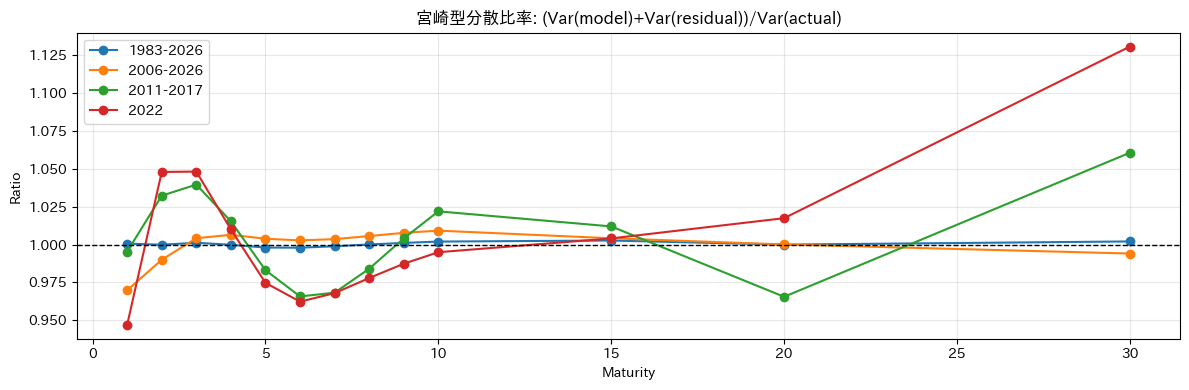

In [6]:
def variance_ratio_table(actual_pct, model_pct, residual_pct, label):
    rows = []
    for sector in SECTOR_NAMES:
        a = actual_pct[sector].dropna()
        m = model_pct.loc[a.index, sector]
        e = residual_pct.loc[a.index, sector]
        var_actual = a.var(ddof=0)
        var_model = m.var(ddof=0)
        var_resid = e.var(ddof=0)
        cov_me = np.cov(m, e, ddof=0)[0, 1]
        ratio = (var_model + var_resid) / var_actual
        rows.append({
            "period": label,
            "sector": sector,
            "maturity": float(sector.replace("Y", "")),
            "var_actual": var_actual,
            "var_model": var_model,
            "var_residual": var_resid,
            "cov_model_residual": cov_me,
            "ratio_model_plus_resid_to_actual": ratio,
            "corr_model_residual": np.corrcoef(m, e)[0, 1],
            "relation": "negative covariance" if ratio > 1 else "positive covariance",
        })
    return pd.DataFrame(rows)

actual_signal_dates = yields.loc[model_yields.index, SECTOR_NAMES]
period_specs = {
    "1983-2026": (None, None),
    "2006-2026": ("2006-01-01", None),
    "2011-2017": ("2011-01-01", "2017-12-31"),
    "2022": ("2022-01-01", "2022-12-31"),
}

vr_tables = []
for label, (start, end) in period_specs.items():
    idx = model_yields.index
    if start is not None:
        idx = idx[idx >= pd.Timestamp(start)]
    if end is not None:
        idx = idx[idx <= pd.Timestamp(end)]
    vr_tables.append(variance_ratio_table(actual_signal_dates.loc[idx], model_yields.loc[idx], residuals.loc[idx], label))
variance_ratio = pd.concat(vr_tables, ignore_index=True)

pivot_ratio = variance_ratio.pivot(index="sector", columns="period", values="ratio_model_plus_resid_to_actual").loc[SECTOR_NAMES]
display(pivot_ratio.style.format("{:.1%}"))

fig, ax = plt.subplots(figsize=(12, 4))
for label in ["1983-2026", "2006-2026", "2011-2017", "2022"]:
    tmp = variance_ratio[variance_ratio["period"] == label]
    ax.plot(tmp["maturity"], tmp["ratio_model_plus_resid_to_actual"], marker="o", label=label)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
ax.set_title("宮崎型分散比率: (Var(model)+Var(residual))/Var(actual)")
ax.set_xlabel("Maturity")
ax.set_ylabel("Ratio")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 7. ウェイト形状を Bullet / Barbell / Cash に分類する

宮崎論文の実証解釈では、6-7年中心のブレット型から、1-3年と15-20年を組み合わせるバーベル型へ切り替わることが重要だった。

ここでは06のウェイトを、次のバケットで分類する。

- Short: 1Y, 2Y, 3Y
- Belly: 4Yから10Y
- Long: 15Y, 20Y, 30Y
- Cash: Cash

形状分類は、診断のための近似である。厳密な最適化制約ではなく、「戦略がどのような形の賭けをしていたか」を読むためのラベルである。

shape,Barbell,Bullet,Cash,Long,Mixed,Short
strategy,,,,,,
MZ_SIGNAL6_CASH,53,258,5,30,119,48
MZ_SIGNAL6_NO_CASH,72,268,0,33,55,85
MZ_SIMPLE_TREND_BEI_CASH,34,129,236,12,72,30
MZ_SIMPLE_TREND_CASH,36,140,209,13,82,33
MZ_TREND_CASH_ADVANCED_V2,33,235,91,22,111,21


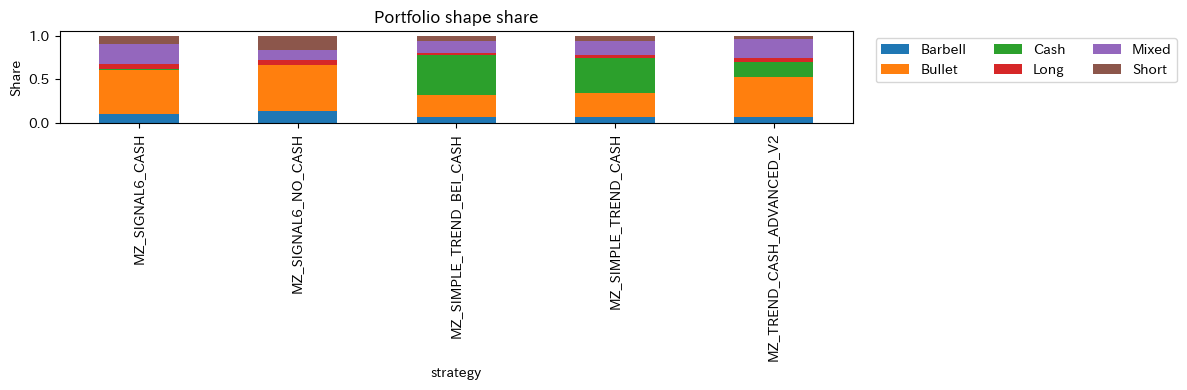

In [7]:
SHORT_SECTORS = ["1Y", "2Y", "3Y"]
BELLY_SECTORS = ["4Y", "5Y", "6Y", "7Y", "8Y", "9Y", "10Y"]
LONG_SECTORS = ["15Y", "20Y", "30Y"]


def classify_shape(row):
    short = row[SHORT_SECTORS].sum()
    belly = row[BELLY_SECTORS].sum()
    long = row[LONG_SECTORS].sum()
    cash = row["Cash"]
    if cash >= 0.70:
        return "Cash"
    if short >= 0.60:
        return "Short"
    if long >= 0.60:
        return "Long"
    if belly >= 0.60:
        return "Bullet"
    if short + long >= 0.60 and short >= 0.20 and long >= 0.20:
        return "Barbell"
    return "Mixed"

shape_rows = []
for strategy, wdf in weights.items():
    for dt, row in wdf.iterrows():
        if dt not in regime_df["signal_date"].values:
            continue
        shape_rows.append({
            "strategy": strategy,
            "signal_date": dt,
            "shape": classify_shape(row),
            "short_weight": row[SHORT_SECTORS].sum(),
            "belly_weight": row[BELLY_SECTORS].sum(),
            "long_weight": row[LONG_SECTORS].sum(),
            "cash_weight": row["Cash"],
            "duration_proxy_weighted_maturity": float(np.dot(row[SECTOR_NAMES], MATURITIES)),
        })
portfolio_shape = pd.DataFrame(shape_rows)
portfolio_shape = portfolio_shape.merge(regime_df, on="signal_date", how="left")
portfolio_shape["return_date"] = portfolio_shape["return_date"].fillna(portfolio_shape["signal_date"] + pd.offsets.MonthEnd(1))

shape_counts = portfolio_shape.pivot_table(index="strategy", columns="shape", values="signal_date", aggfunc="count", fill_value=0)
display(shape_counts)

fig, ax = plt.subplots(figsize=(12, 4))
shape_counts.div(shape_counts.sum(axis=1), axis=0).plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Portfolio shape share")
ax.set_ylabel("Share")
ax.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 8. 形状別の実現リターン

次に、形状ラベルごとの翌月リターンを確認する。ここでは取引コスト控除前のグロスリターンを使う。理由は、CA&RDシグナルそのものの良し悪しを見たいからである。

`strategy_return - BM_equal` を見ることで、その形状を取った月にベンチマーク対比で勝っていたかを確認する。

In [8]:
returns_gross_named = returns_gross.copy()
returns_gross_named.index.name = "return_date"

shape_perf_rows = []
for _, row in portfolio_shape.iterrows():
    strategy = row["strategy"]
    ret_dt = row["return_date"]
    if ret_dt not in returns_gross_named.index or strategy not in returns_gross_named.columns:
        continue
    strategy_return = returns_gross_named.loc[ret_dt, strategy]
    bm_return = returns_gross_named.loc[ret_dt, "BM_equal"]
    cash_ret = returns_gross_named.loc[ret_dt, "CASH_3M"]
    shape_perf_rows.append({
        **row.to_dict(),
        "strategy_return": strategy_return,
        "bm_return": bm_return,
        "cash_return_realized": cash_ret,
        "excess_vs_bm": strategy_return - bm_return,
        "excess_vs_cash": strategy_return - cash_ret,
    })
shape_perf = pd.DataFrame(shape_perf_rows)

shape_summary = shape_perf.groupby(["strategy", "shape"]).agg(
    months=("strategy_return", "size"),
    avg_monthly_return=("strategy_return", "mean"),
    ann_arith_return=("strategy_return", lambda x: x.mean() * 12),
    avg_excess_vs_bm=("excess_vs_bm", "mean"),
    ann_excess_vs_bm=("excess_vs_bm", lambda x: x.mean() * 12),
    hit_vs_bm=("excess_vs_bm", lambda x: (x > 0).mean()),
    avg_next_2y_bp=("next_DGS2_change_bp", "mean"),
    avg_next_10y_bp=("next_DGS10_change_bp", "mean"),
).reset_index()

display(shape_summary.sort_values(["strategy", "ann_excess_vs_bm"], ascending=[True, False]).style.format({
    "avg_monthly_return": "{:.2%}",
    "ann_arith_return": "{:.2%}",
    "avg_excess_vs_bm": "{:.2%}",
    "ann_excess_vs_bm": "{:.2%}",
    "hit_vs_bm": "{:.1%}",
    "avg_next_2y_bp": "{:.2f}",
    "avg_next_10y_bp": "{:.2f}",
}))

,strategy,shape,months,avg_monthly_return,ann_arith_return,avg_excess_vs_bm,ann_excess_vs_bm,hit_vs_bm,avg_next_2y_bp,avg_next_10y_bp
2,MZ_SIGNAL6_CASH,Cash,5,0.43%,5.18%,1.45%,17.45%,100.0%,10.60,24.80
3,MZ_SIGNAL6_CASH,Long,30,1.91%,22.97%,0.74%,8.90%,60.0%,-11.00,-7.83
0,MZ_SIGNAL6_CASH,Barbell,53,1.08%,12.99%,0.24%,2.83%,71.7%,-6.30,-9.58
1,MZ_SIGNAL6_CASH,Bullet,258,0.91%,10.91%,0.23%,2.81%,63.6%,-1.29,-2.20
4,MZ_SIGNAL6_CASH,Mixed,119,0.37%,4.41%,0.17%,2.05%,58.0%,1.07,2.76
5,MZ_SIGNAL6_CASH,Short,48,0.10%,1.22%,0.14%,1.63%,62.5%,3.73,3.27
8,MZ_SIGNAL6_NO_CASH,Long,33,1.80%,21.65%,0.72%,8.61%,60.6%,-9.88,-6.73
7,MZ_SIGNAL6_NO_CASH,Bullet,268,0.88%,10.54%,0.24%,2.89%,64.2%,-1.11,-1.94
6,MZ_SIGNAL6_NO_CASH,Barbell,72,0.71%,8.54%,0.20%,2.38%,65.3%,-4.18,-4.19
9,MZ_SIGNAL6_NO_CASH,Mixed,55,0.35%,4.22%,0.19%,2.27%,54.5%,5.20,5.31


## 9. レジーム別パフォーマンス

CA&RDは、カーブ不変シナリオを仮定する。したがって、実際に金利が動く局面でどれだけ耐えられるかが重要である。

ここでは翌月の2年金利と10年金利の変化で、簡易的に次のレジームを作る。

- `rally`: 2年・10年の平均変化が -5bp 未満
- `selloff`: 2年・10年の平均変化が +5bp 超
- `range`: その間
- `steepening`: 10年金利変化 - 2年金利変化が +5bp 超
- `flattening`: 10年金利変化 - 2年金利変化が -5bp 未満
- `parallel`: その間

この分類により、CA&RDがどの金利局面で効き、Simple Trend Cashがどの局面で損失を削ったかを見る。

In [9]:
regime_perf_rows = []
for ret_dt, r in returns_gross_named.iterrows():
    sig_dt = ret_dt - pd.offsets.MonthEnd(1)
    regime_match = regime_df[regime_df["return_date"] == ret_dt]
    if regime_match.empty:
        continue
    regime = regime_match.iloc[0]["rate_regime"]
    for strategy in ["BM_equal", "MZ_SIGNAL6_CASH", "MZ_SIMPLE_TREND_CASH", "MZ_TREND_CASH_ADVANCED_V2", "MZ_SIMPLE_TREND_BEI_CASH"]:
        regime_perf_rows.append({
            "strategy": strategy,
            "return_date": ret_dt,
            "rate_regime": regime,
            "strategy_return": r[strategy],
            "excess_vs_bm": r[strategy] - r["BM_equal"],
            "excess_vs_cash": r[strategy] - r["CASH_3M"],
        })
regime_perf = pd.DataFrame(regime_perf_rows)

regime_summary = regime_perf.groupby(["strategy", "rate_regime"]).agg(
    months=("strategy_return", "size"),
    ann_return=("strategy_return", lambda x: x.mean() * 12),
    ann_excess_vs_bm=("excess_vs_bm", lambda x: x.mean() * 12),
    hit_vs_bm=("excess_vs_bm", lambda x: (x > 0).mean()),
).reset_index()

display(regime_summary.pivot(index="rate_regime", columns="strategy", values="ann_return").style.format("{:.2%}"))
display(regime_summary.pivot(index="rate_regime", columns="strategy", values="ann_excess_vs_bm").style.format("{:.2%}"))

strategy,BM_equal,MZ_SIGNAL6_CASH,MZ_SIMPLE_TREND_BEI_CASH,MZ_SIMPLE_TREND_CASH,MZ_TREND_CASH_ADVANCED_V2
rate_regime,,,,,
flattening_rally,28.97%,34.23%,22.85%,24.27%,30.12%
flattening_range,10.87%,13.32%,6.65%,7.30%,10.50%
flattening_selloff,-7.62%,-4.29%,0.20%,0.31%,-2.27%
parallel_rally,20.42%,26.80%,13.79%,14.71%,23.20%
parallel_range,4.83%,7.80%,5.15%,5.82%,7.02%
parallel_selloff,-10.63%,-10.84%,-1.27%,-1.41%,-6.95%
steepening_rally,21.88%,24.46%,17.06%,17.65%,23.00%
steepening_range,-0.95%,1.99%,3.64%,2.87%,2.49%
steepening_selloff,-17.55%,-17.03%,-7.97%,-8.31%,-13.47%


strategy,BM_equal,MZ_SIGNAL6_CASH,MZ_SIMPLE_TREND_BEI_CASH,MZ_SIMPLE_TREND_CASH,MZ_TREND_CASH_ADVANCED_V2
rate_regime,,,,,
flattening_rally,0.00%,5.26%,-6.11%,-4.70%,1.16%
flattening_range,0.00%,2.45%,-4.22%,-3.57%,-0.37%
flattening_selloff,0.00%,3.33%,7.83%,7.93%,5.35%
parallel_rally,0.00%,6.38%,-6.63%,-5.71%,2.78%
parallel_range,0.00%,2.98%,0.32%,0.99%,2.19%
parallel_selloff,0.00%,-0.21%,9.35%,9.22%,3.68%
steepening_rally,0.00%,2.58%,-4.82%,-4.23%,1.12%
steepening_range,0.00%,2.94%,4.59%,3.81%,3.43%
steepening_selloff,0.00%,0.52%,9.58%,9.24%,4.08%


## 10. シグナル成分のポートフォリオ寄与

MZシグナルの成分を、実際のウェイトで加重平均する。これにより、戦略が平均的に何を買っていたのかを、期待リターンの内訳として読む。

特に見るべき点は次である。

- `carry_m`: 単純な利回り収入
- `model_roll_linear_m`: モデルカーブ上のロールダウン
- `residual_alpha_linear_m`: 割高・割安の平均回帰
- `convexity_mz_m`: 二次項
- `trend_penalty_m`: Simple Trend Cashが控除した名目金利トレンド損失

`trend_penalty_m` は実際のシグナルから控除される値なので、正の数で「どれだけ減点したか」を表示する。

,strategy,months,carry_ann,model_roll_ann,residual_alpha_ann,convexity_ann,mz_signal_ann,trend_penalty_ann,avg_cash,avg_bond
0,MZ_SIGNAL6_CASH,513,4.62%,1.58%,0.14%,0.03%,6.37%,0.00%,9.7%,90.3%
1,MZ_SIGNAL6_NO_CASH,513,4.91%,1.55%,0.15%,0.03%,6.64%,0.00%,0.0%,100.0%
2,MZ_SIMPLE_TREND_BEI_CASH,513,2.46%,0.84%,0.09%,0.02%,3.41%,0.25%,52.6%,47.4%
3,MZ_SIMPLE_TREND_CASH,513,2.56%,0.93%,0.09%,0.02%,3.60%,0.32%,48.5%,51.5%
4,MZ_TREND_CASH_ADVANCED_V2,513,3.99%,1.36%,0.11%,0.03%,5.49%,4.45%,25.6%,74.4%


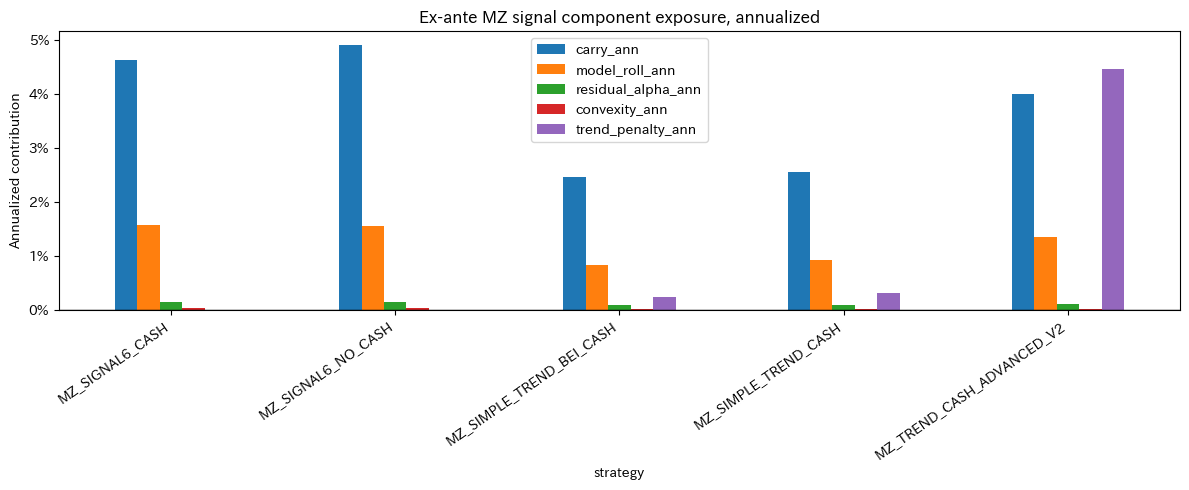

In [10]:
comp_wide = signal_components.set_index(["signal_date", "sector"])

component_exposure_rows = []
for strategy, wdf in weights.items():
    for dt, row in wdf.iterrows():
        if dt not in model_yields.index:
            continue
        comp = comp_wide.loc[dt]
        wb = row[SECTOR_NAMES]
        trend_move = float(comp["nominal_trend_move_m"].iloc[0])
        trend_penalty = float((wb.values * comp["duration"].values * trend_move).sum())
        component_exposure_rows.append({
            "strategy": strategy,
            "signal_date": dt,
            "carry_m": float((wb.values * comp["carry_m"].values).sum()),
            "model_roll_linear_m": float((wb.values * comp["model_roll_linear_m"].values).sum()),
            "residual_alpha_linear_m": float((wb.values * comp["residual_alpha_linear_m"].values).sum()),
            "convexity_mz_m": float((wb.values * comp["convexity_mz_m"].values).sum()),
            "mz_signal6_weighted_m": float((wb.values * comp["mz_signal6"].values).sum()),
            "trend_penalty_m": trend_penalty if "SIMPLE_TREND" in strategy or "ADVANCED" in strategy else 0.0,
            "cash_weight": float(row["Cash"]),
            "bond_weight": float(row[SECTOR_NAMES].sum()),
        })
component_exposure = pd.DataFrame(component_exposure_rows)

component_summary = component_exposure.groupby("strategy").agg(
    months=("signal_date", "size"),
    carry_ann=("carry_m", lambda x: x.mean() * 12),
    model_roll_ann=("model_roll_linear_m", lambda x: x.mean() * 12),
    residual_alpha_ann=("residual_alpha_linear_m", lambda x: x.mean() * 12),
    convexity_ann=("convexity_mz_m", lambda x: x.mean() * 12),
    mz_signal_ann=("mz_signal6_weighted_m", lambda x: x.mean() * 12),
    trend_penalty_ann=("trend_penalty_m", lambda x: x.mean() * 12),
    avg_cash=("cash_weight", "mean"),
    avg_bond=("bond_weight", "mean"),
).reset_index()

display(component_summary.style.format({
    "carry_ann": "{:.2%}",
    "model_roll_ann": "{:.2%}",
    "residual_alpha_ann": "{:.2%}",
    "convexity_ann": "{:.2%}",
    "mz_signal_ann": "{:.2%}",
    "trend_penalty_ann": "{:.2%}",
    "avg_cash": "{:.1%}",
    "avg_bond": "{:.1%}",
}))

plot_cols = ["carry_ann", "model_roll_ann", "residual_alpha_ann", "convexity_ann", "trend_penalty_ann"]
plot_df = component_summary.set_index("strategy")[plot_cols]
fig, ax = plt.subplots(figsize=(12, 5))
plot_df.plot(kind="bar", ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Ex-ante MZ signal component exposure, annualized")
ax.set_ylabel("Annualized contribution")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 11. クロスセクショナルIC: シグナル成分は翌月リターンを説明しているか

各月の13セクター内で、シグナル成分と翌月実現リターンの順位相関を計算する。

これは、時系列の総リターンではなく、「その月に高く評価した年限が、翌月本当に相対的に良かったか」を見る診断である。

注意点として、CA&RDシグナルは半年ホライズンを月次化したものであり、1か月の順位相関が常に高い必要はない。それでも、長期平均でどの成分が年限選択に効いているかを見る補助になる。

In [11]:
merged_signal_realized = signal_components.merge(
    realized_long[["signal_date", "sector", "sector_return"]],
    on=["signal_date", "sector"],
    how="left",
)

ic_rows = []
for dt, g in merged_signal_realized.groupby("signal_date"):
    for col in ["carry_m", "model_roll_linear_m", "residual_alpha_linear_m", "convexity_mz_m", "mz_signal6", "card_actual_signal6", "card_model_signal6"]:
        ic_rows.append({
            "signal_date": dt,
            "component": col,
            "spearman_ic": g[col].corr(g["sector_return"], method="spearman"),
            "pearson_ic": g[col].corr(g["sector_return"], method="pearson"),
        })
ic_df = pd.DataFrame(ic_rows)
ic_summary = ic_df.groupby("component").agg(
    months=("signal_date", "size"),
    avg_spearman_ic=("spearman_ic", "mean"),
    t_spearman_ic=("spearman_ic", lambda x: x.mean() / (x.std(ddof=1) / np.sqrt(len(x)))),
    positive_ic_rate=("spearman_ic", lambda x: (x > 0).mean()),
    avg_pearson_ic=("pearson_ic", "mean"),
).reset_index()

display(ic_summary.sort_values("avg_spearman_ic", ascending=False).style.format({
    "avg_spearman_ic": "{:.3f}",
    "t_spearman_ic": "{:.2f}",
    "positive_ic_rate": "{:.1%}",
    "avg_pearson_ic": "{:.3f}",
}))

,component,months,avg_spearman_ic,t_spearman_ic,positive_ic_rate,avg_pearson_ic
5,mz_signal6,513,0.135,5.79,60.6%,0.153
0,card_actual_signal6,513,0.132,5.52,58.7%,0.140
1,card_model_signal6,513,0.121,5.08,58.9%,0.133
2,carry_m,513,0.117,3.88,56.1%,0.126
4,model_roll_linear_m,513,0.050,2.55,53.6%,0.082
6,residual_alpha_linear_m,513,0.036,2.22,55.8%,0.042
3,convexity_mz_m,513,0.014,0.76,50.7%,0.079


## 12. 実現リターンのバケット寄与

最後に、06の各戦略リターンを、Short / Belly / Long / Cash のどこから得ていたかに分ける。

これは、宮崎論文の「バーベル型がセルオフ局面で効いた」という議論を、私たちの実装で検証するためのものだ。

In [12]:
realized_wide = realized_long.pivot(index="signal_date", columns="sector", values="sector_return")
regime_by_signal = regime_df.set_index("signal_date")

bucket_contrib_rows = []
for strategy, wdf in weights.items():
    for dt, row in wdf.iterrows():
        if dt not in realized_wide.index:
            continue
        r = realized_wide.loc[dt]
        short_contrib = float((row[SHORT_SECTORS] * r[SHORT_SECTORS]).sum())
        belly_contrib = float((row[BELLY_SECTORS] * r[BELLY_SECTORS]).sum())
        long_contrib = float((row[LONG_SECTORS] * r[LONG_SECTORS]).sum())
        cash_contrib = float(row["Cash"] * regime_by_signal.loc[dt, "cash_return"])
        total_rebuilt = short_contrib + belly_contrib + long_contrib + cash_contrib
        ret_dt = regime_by_signal.loc[dt, "return_date"]
        bucket_contrib_rows.append({
            "strategy": strategy,
            "signal_date": dt,
            "return_date": ret_dt,
            "rate_regime": regime_by_signal.loc[dt, "rate_regime"],
            "shape": classify_shape(row),
            "short_contrib": short_contrib,
            "belly_contrib": belly_contrib,
            "long_contrib": long_contrib,
            "cash_contrib": cash_contrib,
            "rebuilt_gross_return": total_rebuilt,
            "excel_gross_return": returns_gross.loc[ret_dt, strategy],
            "bm_return": returns_gross.loc[ret_dt, "BM_equal"],
        })
bucket_contrib = pd.DataFrame(bucket_contrib_rows)
bucket_contrib["rebuild_diff"] = bucket_contrib["rebuilt_gross_return"] - bucket_contrib["excel_gross_return"]

bucket_summary = bucket_contrib.groupby("strategy").agg(
    months=("signal_date", "size"),
    short_ann=("short_contrib", lambda x: x.mean() * 12),
    belly_ann=("belly_contrib", lambda x: x.mean() * 12),
    long_ann=("long_contrib", lambda x: x.mean() * 12),
    cash_ann=("cash_contrib", lambda x: x.mean() * 12),
    gross_ann=("rebuilt_gross_return", lambda x: x.mean() * 12),
    max_rebuild_abs_diff=("rebuild_diff", lambda x: np.abs(x).max()),
).reset_index()

display(bucket_summary.style.format({
    "short_ann": "{:.2%}",
    "belly_ann": "{:.2%}",
    "long_ann": "{:.2%}",
    "cash_ann": "{:.2%}",
    "gross_ann": "{:.2%}",
    "max_rebuild_abs_diff": "{:.2e}",
}))

regime_bucket_summary = bucket_contrib.groupby(["strategy", "rate_regime"]).agg(
    months=("signal_date", "size"),
    short_ann=("short_contrib", lambda x: x.mean() * 12),
    belly_ann=("belly_contrib", lambda x: x.mean() * 12),
    long_ann=("long_contrib", lambda x: x.mean() * 12),
    cash_ann=("cash_contrib", lambda x: x.mean() * 12),
    gross_ann=("rebuilt_gross_return", lambda x: x.mean() * 12),
).reset_index()

display(regime_bucket_summary[regime_bucket_summary["strategy"].isin(["MZ_SIGNAL6_CASH", "MZ_SIMPLE_TREND_CASH"])].style.format({
    "short_ann": "{:.2%}",
    "belly_ann": "{:.2%}",
    "long_ann": "{:.2%}",
    "cash_ann": "{:.2%}",
    "gross_ann": "{:.2%}",
}))

,strategy,months,short_ann,belly_ann,long_ann,cash_ann,gross_ann,max_rebuild_abs_diff
0,MZ_SIGNAL6_CASH,513,0.42%,3.31%,5.32%,0.32%,9.36%,5.55e-17
1,MZ_SIGNAL6_NO_CASH,513,0.69%,3.27%,5.21%,0.00%,9.18%,5.55e-17
2,MZ_SIMPLE_TREND_BEI_CASH,513,0.54%,1.99%,3.27%,1.77%,7.57%,5.55e-17
3,MZ_SIMPLE_TREND_CASH,513,0.54%,2.03%,3.68%,1.74%,7.99%,5.55e-17
4,MZ_TREND_CASH_ADVANCED_V2,513,0.30%,3.14%,4.92%,0.78%,9.14%,5.55e-17


,strategy,rate_regime,months,short_ann,belly_ann,long_ann,cash_ann,gross_ann
0,MZ_SIGNAL6_CASH,flattening_rally,93,0.77%,14.13%,19.22%,0.11%,34.23%
1,MZ_SIGNAL6_CASH,flattening_range,21,0.12%,3.77%,9.29%,0.14%,13.32%
2,MZ_SIGNAL6_CASH,flattening_selloff,78,-0.36%,-3.31%,-0.89%,0.28%,-4.29%
3,MZ_SIGNAL6_CASH,parallel_rally,55,1.03%,10.91%,14.60%,0.26%,26.80%
4,MZ_SIGNAL6_CASH,parallel_range,38,0.48%,2.89%,4.06%,0.38%,7.80%
5,MZ_SIGNAL6_CASH,parallel_selloff,60,-0.04%,-4.44%,-6.72%,0.36%,-10.84%
6,MZ_SIGNAL6_CASH,steepening_rally,69,1.44%,9.17%,13.38%,0.48%,24.46%
7,MZ_SIGNAL6_CASH,steepening_range,29,0.29%,1.22%,-0.06%,0.54%,1.99%
8,MZ_SIGNAL6_CASH,steepening_selloff,70,-0.17%,-7.85%,-9.43%,0.42%,-17.03%
27,MZ_SIMPLE_TREND_CASH,flattening_rally,93,0.63%,9.36%,12.81%,1.48%,24.27%


## 13. 機械チェックとExcel保存

診断ノートで作ったデータが06の結果と整合しているかを確認する。

- モデル利回り・残差・シグナル成分にNaN/infがない
- 実現リターン再構築が06のグロスリターンと一致する
- 分散比率が有限
- 全月に形状ラベルが付いている

保存するシートは、後からObsidianや別ノートブックで再利用しやすいように、long形式を中心にする。

In [13]:
checks = []
checks.append(("signal_components finite", np.isfinite(signal_components.select_dtypes(include=[np.number]).values).all()))
checks.append(("realized_long finite", np.isfinite(realized_long.select_dtypes(include=[np.number]).values).all()))
checks.append(("model_yields finite", np.isfinite(model_yields.values).all()))
checks.append(("residuals finite", np.isfinite(residuals.values).all()))
checks.append(("variance_ratio finite", np.isfinite(variance_ratio.select_dtypes(include=[np.number]).values).all()))
checks.append(("portfolio_shape no missing shape", portfolio_shape["shape"].notna().all()))
checks.append(("bucket rebuild max diff small", bucket_contrib["rebuild_diff"].abs().max() < 1e-10))

check_df = pd.DataFrame(checks, columns=["check", "ok"])
display(check_df)

if not check_df["ok"].all():
    raise RuntimeError("diagnostic checks failed")

with pd.ExcelWriter(DIAGNOSTIC_PATH) as writer:
    signal_components.to_excel(writer, sheet_name="signal_components", index=False)
    realized_long.to_excel(writer, sheet_name="realized_sector_returns", index=False)
    model_yields.to_excel(writer, sheet_name="model_yields")
    residuals.to_excel(writer, sheet_name="residuals")
    factors.to_excel(writer, sheet_name="factor_values")
    regime_df.to_excel(writer, sheet_name="rate_regimes", index=False)
    variance_ratio.to_excel(writer, sheet_name="variance_ratio", index=False)
    portfolio_shape.to_excel(writer, sheet_name="portfolio_shape", index=False)
    shape_summary.to_excel(writer, sheet_name="shape_summary", index=False)
    regime_summary.to_excel(writer, sheet_name="regime_summary", index=False)
    component_exposure.to_excel(writer, sheet_name="component_exposure", index=False)
    component_summary.to_excel(writer, sheet_name="component_summary", index=False)
    ic_df.to_excel(writer, sheet_name="cross_sectional_ic", index=False)
    ic_summary.to_excel(writer, sheet_name="ic_summary", index=False)
    bucket_contrib.to_excel(writer, sheet_name="bucket_contrib", index=False)
    bucket_summary.to_excel(writer, sheet_name="bucket_summary", index=False)
    regime_bucket_summary.to_excel(writer, sheet_name="regime_bucket_summary", index=False)
    check_df.to_excel(writer, sheet_name="checks", index=False)

print(f"保存完了: {DIAGNOSTIC_PATH}")

,check,ok
0,signal_components finite,True
1,realized_long finite,True
2,model_yields finite,True
3,residuals finite,True
4,variance_ratio finite,True
5,portfolio_shape no missing shape,True
6,bucket rebuild max diff small,True


保存完了: ../data/carry_roll_down_diagnostics.xlsx


## 14. 図で読む診断結果

ここからは、表だけでは見えにくい点を4つの図で確認する。

1つ目はシグナル成分別ICである。これは「どの成分が翌月の年限間リターン差を説明しているか」を見る。

2つ目は金利局面別のBM対比超過リターンである。これは「MZ単体がラリーを取りに行く戦略なのか、Simple Trend Cashがセルオフ防御に寄った戦略なのか」を分けて見る。

3つ目は `MZ_SIMPLE_TREND_CASH` のポートフォリオ形状別成績である。これは「Cash逃避だけでなく、BulletやBarbellを取った月に本当に価値が出ているか」を見る。

4つ目は年限バケット別の実現リターン寄与である。これは「最終リターンがDurationだけで出たのか、Cash防御や年限選択も効いたのか」を確認する。

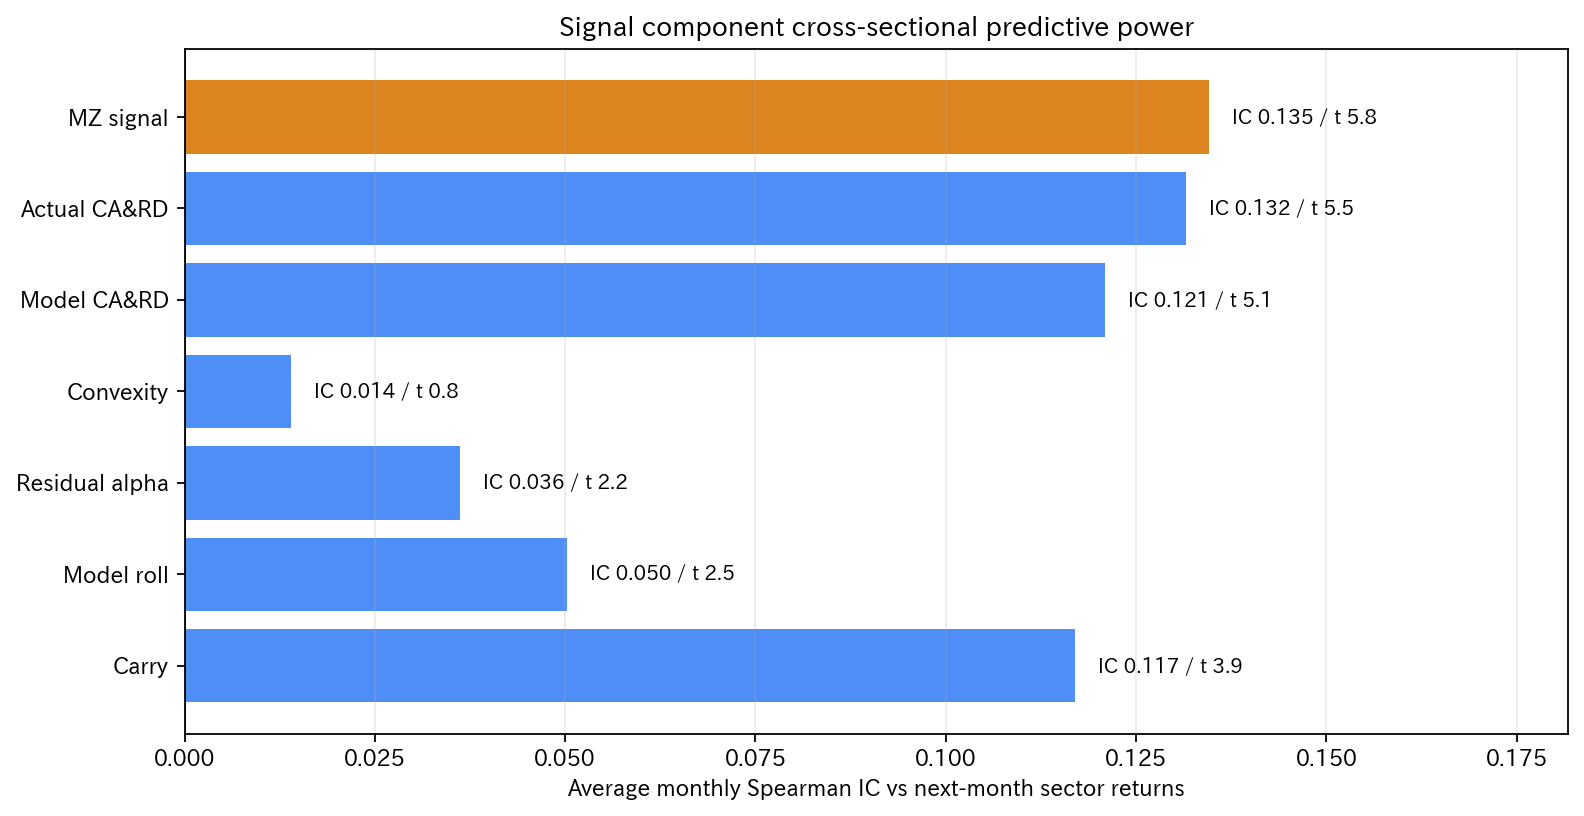

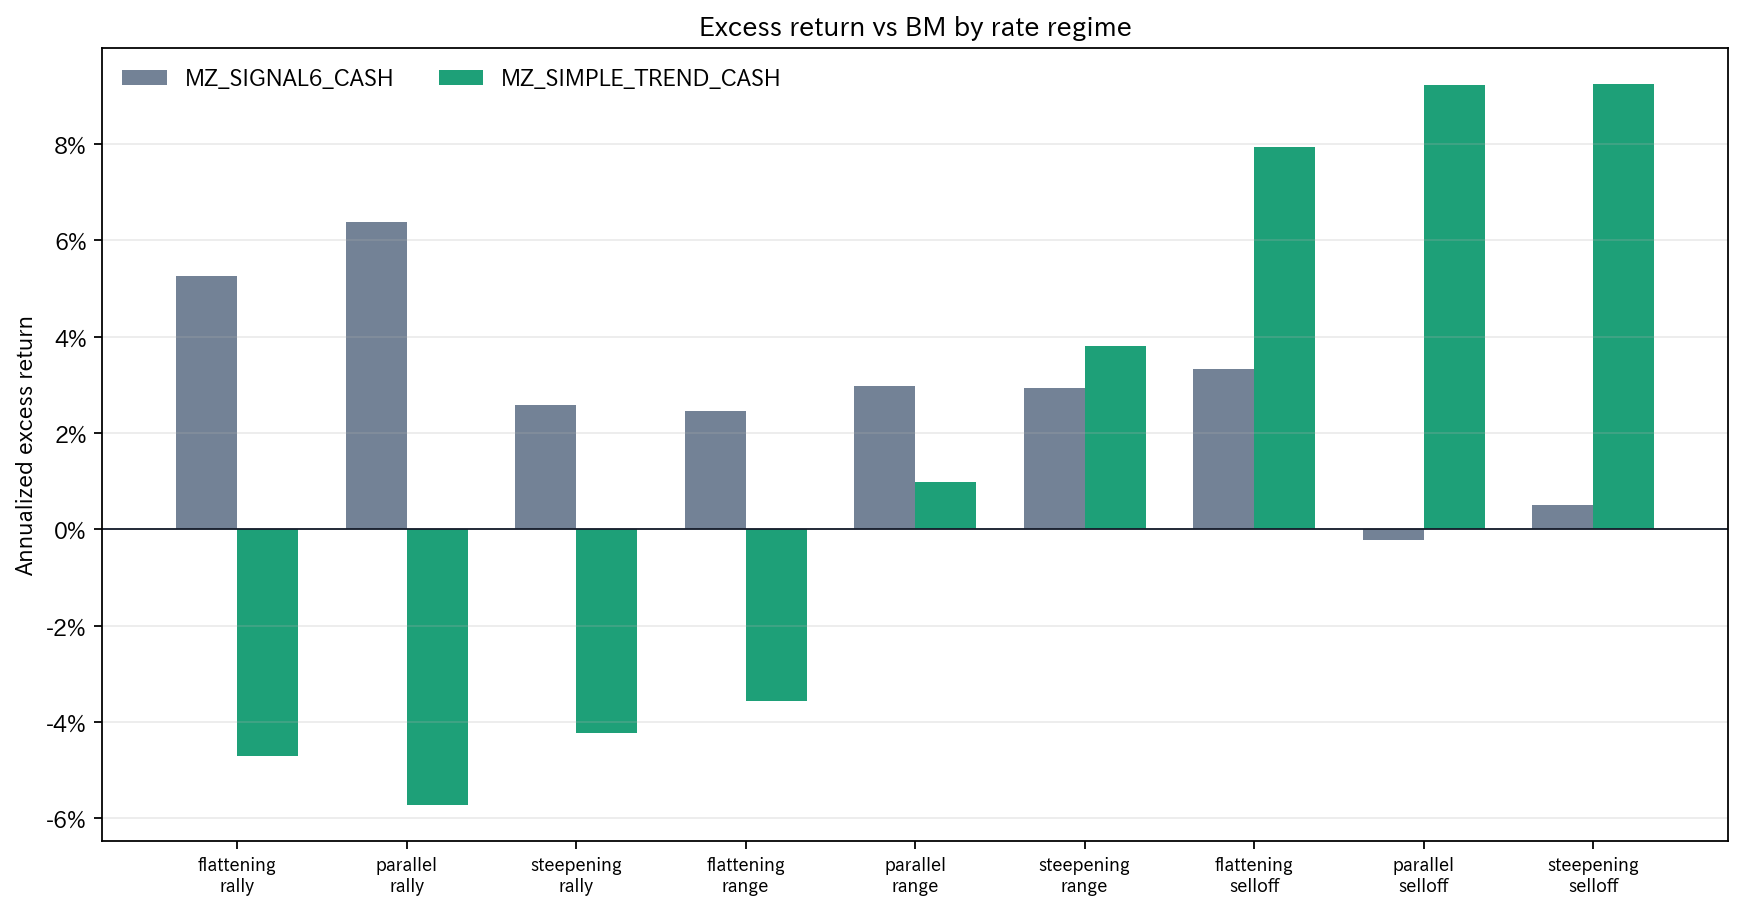

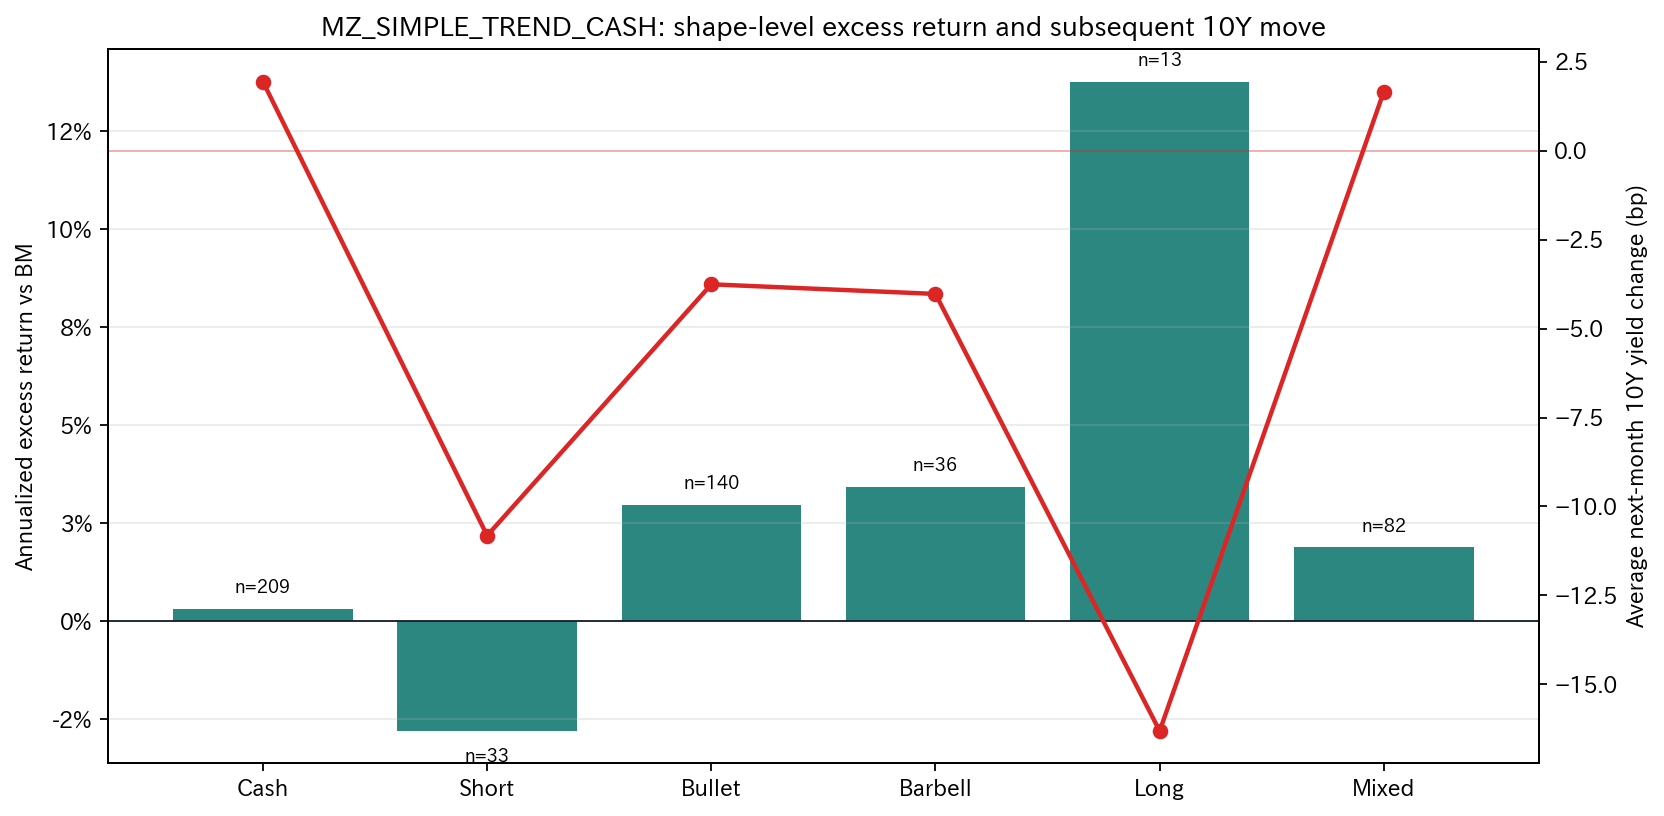

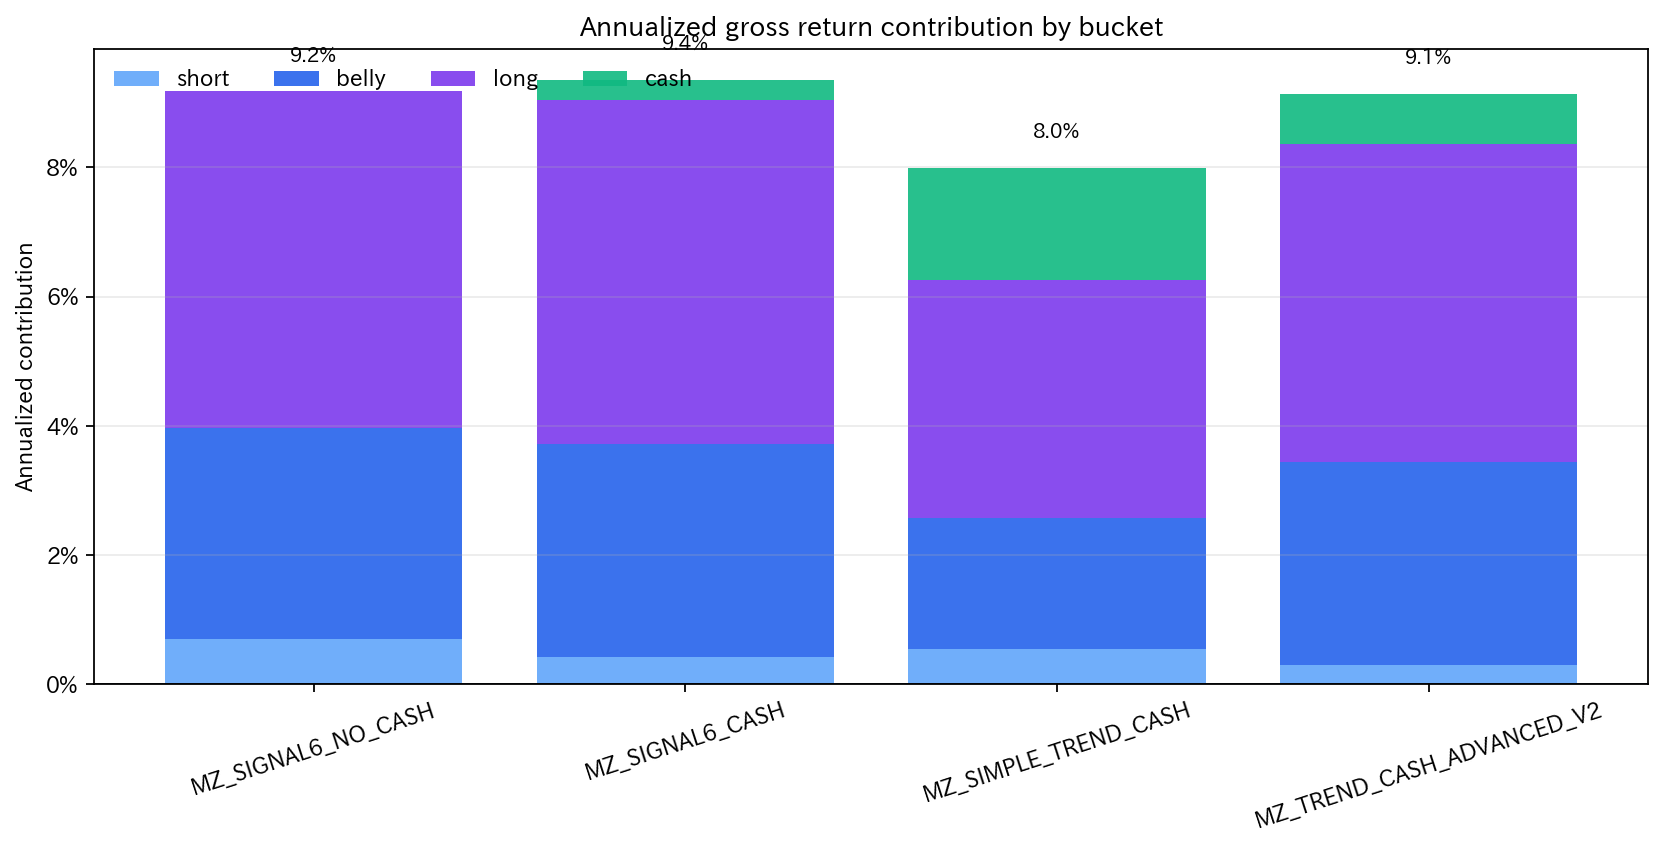

Saved figures to: /Users/michi/Documents/program/0007_Bond_Strategy/001_miyazaki/data/carry_roll_down_diagnostic_figures


In [14]:
from matplotlib.ticker import FuncFormatter

FIG_DIR = Path("../data/carry_roll_down_diagnostic_figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def pct_axis(ax):
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0%}"))

# 1. Cross-sectional IC by component.
ic_order = [
    "carry_m",
    "model_roll_linear_m",
    "residual_alpha_linear_m",
    "convexity_mz_m",
    "card_model_signal6",
    "card_actual_signal6",
    "mz_signal6",
]
ic_labels = {
    "carry_m": "Carry",
    "model_roll_linear_m": "Model roll",
    "residual_alpha_linear_m": "Residual alpha",
    "convexity_mz_m": "Convexity",
    "card_model_signal6": "Model CA&RD",
    "card_actual_signal6": "Actual CA&RD",
    "mz_signal6": "MZ signal",
}
ic_plot = ic_summary.set_index("component").loc[ic_order].reset_index()
fig, ax = plt.subplots(figsize=(10, 5.2), dpi=160)
colors = ["#3B82F6" if c != "mz_signal6" else "#D97706" for c in ic_plot["component"]]
ax.barh([ic_labels[c] for c in ic_plot["component"]], ic_plot["avg_spearman_ic"], color=colors, alpha=0.9)
for y, row in enumerate(ic_plot.itertuples()):
    ax.text(row.avg_spearman_ic + 0.003, y, f"IC {row.avg_spearman_ic:.3f} / t {row.t_spearman_ic:.1f}", va="center", fontsize=9)
ax.axvline(0, color="#111827", lw=0.8)
ax.set_title("Signal component cross-sectional predictive power")
ax.set_xlabel("Average monthly Spearman IC vs next-month sector returns")
ax.set_xlim(0, max(ic_plot["avg_spearman_ic"]) * 1.35)
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "07_宮崎_ic_summary.png", bbox_inches="tight")
plt.show()

# 2. Regime excess return.
strategies_for_regime = ["MZ_SIGNAL6_CASH", "MZ_SIMPLE_TREND_CASH"]
regime_order = [
    "flattening_rally", "parallel_rally", "steepening_rally",
    "flattening_range", "parallel_range", "steepening_range",
    "flattening_selloff", "parallel_selloff", "steepening_selloff",
]
reg_plot = regime_summary[regime_summary["strategy"].isin(strategies_for_regime)].copy()
reg_plot["rate_regime"] = pd.Categorical(reg_plot["rate_regime"], regime_order, ordered=True)
reg_plot = reg_plot.sort_values(["rate_regime", "strategy"])
fig, ax = plt.subplots(figsize=(11, 5.8), dpi=160)
x = np.arange(len(regime_order))
w = 0.36
for j, st in enumerate(strategies_for_regime):
    vals = reg_plot[reg_plot["strategy"].eq(st)].set_index("rate_regime").reindex(regime_order)["ann_excess_vs_bm"].values
    color = "#64748B" if st == "MZ_SIGNAL6_CASH" else "#059669"
    ax.bar(x + (j - 0.5) * w, vals, width=w, label=st, color=color, alpha=0.9)
ax.axhline(0, color="#111827", lw=0.8)
ax.set_title("Excess return vs BM by rate regime")
ax.set_ylabel("Annualized excess return")
ax.set_xticks(x)
ax.set_xticklabels([s.replace("_", "\n") for s in regime_order], fontsize=8)
pct_axis(ax)
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False, ncol=2, loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "08_宮崎_regime_excess.png", bbox_inches="tight")
plt.show()

# 3. Shape-level excess return for MZ_SIMPLE_TREND_CASH.
shape_order = ["Cash", "Short", "Bullet", "Barbell", "Long", "Mixed"]
shape_plot = shape_summary[shape_summary["strategy"].eq("MZ_SIMPLE_TREND_CASH")].copy()
shape_plot["shape"] = pd.Categorical(shape_plot["shape"], shape_order, ordered=True)
shape_plot = shape_plot.sort_values("shape")
fig, ax1 = plt.subplots(figsize=(10.5, 5.2), dpi=160)
ax1.bar(shape_plot["shape"].astype(str), shape_plot["ann_excess_vs_bm"], color="#0F766E", alpha=0.88)
ax1.axhline(0, color="#111827", lw=0.8)
ax1.set_title("MZ_SIMPLE_TREND_CASH: shape-level excess return and subsequent 10Y move")
ax1.set_ylabel("Annualized excess return vs BM")
pct_axis(ax1)
ax1.grid(axis="y", alpha=0.25)
ax2 = ax1.twinx()
ax2.plot(shape_plot["shape"].astype(str), shape_plot["avg_next_10y_bp"], color="#DC2626", marker="o", lw=2)
ax2.axhline(0, color="#DC2626", lw=0.8, alpha=0.4)
ax2.set_ylabel("Average next-month 10Y yield change (bp)")
for x_i, row in enumerate(shape_plot.itertuples()):
    y = row.ann_excess_vs_bm + (0.004 if row.ann_excess_vs_bm >= 0 else -0.008)
    ax1.text(x_i, y, f"n={row.months}", ha="center", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "10_宮崎_shape_summary.png", bbox_inches="tight")
plt.show()

# 4. Bucket contribution.
bucket_strategies = ["MZ_SIGNAL6_NO_CASH", "MZ_SIGNAL6_CASH", "MZ_SIMPLE_TREND_CASH", "MZ_TREND_CASH_ADVANCED_V2"]
bucket_plot = bucket_summary[bucket_summary["strategy"].isin(bucket_strategies)].copy()
bucket_plot = bucket_plot.set_index("strategy").loc[bucket_strategies].reset_index()
contrib_cols = ["short_ann", "belly_ann", "long_ann", "cash_ann"]
contrib_colors = ["#60A5FA", "#2563EB", "#7C3AED", "#10B981"]
fig, ax = plt.subplots(figsize=(10.5, 5.4), dpi=160)
bottom_pos = np.zeros(len(bucket_plot))
bottom_neg = np.zeros(len(bucket_plot))
for col, color in zip(contrib_cols, contrib_colors):
    vals = bucket_plot[col].values
    pos = np.where(vals > 0, vals, 0)
    neg = np.where(vals < 0, vals, 0)
    ax.bar(bucket_plot["strategy"], pos, bottom=bottom_pos, color=color, label=col.replace("_ann", ""), alpha=0.9)
    ax.bar(bucket_plot["strategy"], neg, bottom=bottom_neg, color=color, alpha=0.9)
    bottom_pos += pos
    bottom_neg += neg
for i, row in enumerate(bucket_plot.itertuples()):
    ax.text(i, row.gross_ann + 0.004, f"{row.gross_ann:.1%}", ha="center", va="bottom", fontsize=9)
ax.axhline(0, color="#111827", lw=0.8)
ax.set_title("Annualized gross return contribution by bucket")
ax.set_ylabel("Annualized contribution")
pct_axis(ax)
ax.tick_params(axis="x", rotation=18)
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False, ncol=4, loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "09_宮崎_bucket_contribution.png", bbox_inches="tight")
plt.show()

print(f"Saved figures to: {FIG_DIR.resolve()}")

## 15. 総合解釈: 各グラフから何を読むか

### 15.1 ICグラフ

ICグラフで最初に見るべき点は、`mz_signal6` が一番上に来ていることである。平均Spearman ICは約0.135、t値は約5.8である。これは、MZシグナルで高く評価された年限が、翌月に相対的に良いリターンを出しやすかったことを意味する。

重要なのは、残差補正単体ではなく、キャリー、ロールダウン、残差補正を合わせた総合シグナルが最も強い点である。`carry_m` 単体のICも約0.117と高く、伝統的なキャリーが予測力の中心にある。一方、`residual_alpha_linear_m` はIC約0.036、t値約2.2であり、単体では小さいが統計的には無視しにくい補助項である。

したがって、このグラフからの結論は「宮崎型の強さは残差だけではない」である。キャリー・ロールダウンが主役で、残差補正はそれを少し改善する。宮崎論文の主張に沿って言えば、単純CA&RDだけでは足りないが、残差を足せば相対価値判断が改善する、という読みになる。

### 15.2 金利局面別グラフ

金利局面別グラフは、`MZ_SIGNAL6_CASH` と `MZ_SIMPLE_TREND_CASH` の性格差を最も分かりやすく示している。

`MZ_SIGNAL6_CASH` はラリー局面でもBMに勝っている。flattening rally、parallel rally、steepening rallyのすべてで超過がプラスであり、特にparallel rallyではBM対比で年率6%超の超過を出している。これは、MZシグナルが単に金利上昇を避けるだけの戦略ではなく、金利低下局面でも相対的に良い年限を選べていることを示す。

一方、`MZ_SIMPLE_TREND_CASH` はラリー局面ではBMに劣後する。これは欠陥ではなく、設計上の代償である。直近の金利上昇トレンドを見てDuration損失を控除するため、金利が反転して大きく低下する局面では、Cashや短いDurationに寄りすぎてラリーを取り逃がすことがある。

ただし、selloff局面では解釈が逆になる。`MZ_SIMPLE_TREND_CASH` はflattening selloff、parallel selloff、steepening selloffでBM対比の超過が大きくプラスである。これは、2022年だけの特殊な勝ちではなく、長期的に金利上昇局面の損失を削る構造があることを示す。

### 15.3 ポートフォリオ形状グラフ

形状別グラフでは、`MZ_SIMPLE_TREND_CASH` がCashだけで成り立っているわけではない点を見る。

Cash形状は209か月と多く、翌月の2年金利と10年金利は平均して上昇している。このため、Cash退避は「金利上昇が起きやすい月に出ていた」という意味では合理的である。しかし、Cash形状のBM対比超過は小さい。Cashは大きなアルファ源泉というより、損失回避とボラティリティ低下のための保険である。

BulletとBarbellは、どちらもBM対比でプラスである。Bulletは月数が多く、安定的にリターンを作る中心形状である。Barbellは月数こそ少ないが勝率が高く、宮崎論文が強調した「局面によってブレットからバーベルへ切り替える価値」と整合的である。

Long形状は年率リターンが非常に高いが、月数が13か月しかない。これは「強い金利低下局面でLongを取れた月は大きく効いた」という確認であり、これだけを一般化してLongを増やすべきという意味ではない。

### 15.4 バケット寄与グラフ

バケット寄与グラフでは、最終リターンがどこから来たかを見る。

`MZ_SIGNAL6_NO_CASH` と `MZ_SIGNAL6_CASH` は、LongとBellyの寄与が大きい。これは、宮崎型シグナルが債券内の年限選択、特に中長期のリスクプレミアムを取りに行く戦略であることを示す。

`MZ_SIMPLE_TREND_CASH` では、LongとBellyの寄与は小さくなるが、Cash寄与が大きくなる。これは、Simple TrendがMZの債券アルファを完全に捨てたのではなく、中長期債の寄与を残しながら、悪い局面ではCashで補完していることを示す。

`MZ_TREND_CASH_ADVANCED_V2` は、LongとBellyの寄与をSimple Trendより多く残している。そのため長期リターンは高い。しかし、ルールが増えるため、最終提案としてはSimple Trend Cashを主役にし、V2は改善候補として扱うのが自然である。

### 15.5 最終的な読み筋

この診断から、最終提案のストーリーは次のように整理できる。

- MZシグナルには、翌月の年限間リターン差を説明する横断予測力がある。
- 予測力の中心はキャリー・ロールダウンであり、残差補正は補助的だが有効である。
- MZ単体はラリー局面でも強いが、金利上昇局面ではDuration損失を受ける。
- Simple Trend Cashは、その弱点を直近の金利上昇ペースに基づく単純なDuration損失控除で抑える。
- その代償として、ラリー局面ではBMやMZ単体に劣後しやすい。
- したがって、`MZ_SIMPLE_TREND_CASH` は「最高リターンを狙う宮崎再現」ではなく、「宮崎型の相対価値アルファを残しながら、金利上昇局面の大きな損失を避ける実用戦略」である。

この読み筋は、06の最終提案と整合的である。主役は `MZ_SIMPLE_TREND_CASH`、比較対象は `MZ_SIGNAL6_NO_CASH` と `MZ_SIGNAL6_CASH`、改善候補は `MZ_TREND_CASH_ADVANCED_V2` とする。